
# Predicción de ventas de productos con CRISP-DM

## Titanium Sport Gym

Esta libreta construye un modelo de regresión para predecir:

> **Cuántas unidades de cada producto se venderán durante el siguiente mes.**

Se utiliza la metodología **CRISP-DM**:

1. Comprensión del negocio.
2. Comprensión de los datos.
3. Preparación de los datos.
4. Modelado.
5. Evaluación.
6. Despliegue.

### Decisión sobre las variables

Se utilizarán todas las variables propuestas. No se realizará selección de características.

- `producto`
- `ventas_mes_anterior`
- `promedio_movil_ventas_3_meses`
- `promedio_movil_ventas_6_meses`
- `promedio_movil_ventas_12_meses`
- `vistas_producto_mes_anterior`
- `promedio_movil_vistas_3_meses`

La columna `mes_corte` **no se utilizará como predictor**, porque su función será ordenar los datos y crear una división cronológica sin mezclar el futuro con el pasado.

La variable objetivo es:

- `ventas_mes_siguiente`


## Trazabilidad de columnas del dataset de regresión

| Columna final | Significado en el negocio | Origen en base de datos | Forma de obtención | Uso en el modelo |
|---|---|---|---|---|
| `producto` | Producto para el cual se construye la observación mensual. | `core."Products"` | Se obtiene directamente de `Products.name` para productos con estado `Activo`. | Variable predictora categórica. |
| `mes_corte` | Mes histórico que resume el comportamiento del producto antes de predecir el mes siguiente. | Serie mensual generada en SQL con `GENERATE_SERIES`. | Se calcula al crear todas las combinaciones producto-mes dentro del periodo definido. | Variable temporal para ordenar, dividir entrenamiento/validación/prueba y evitar fuga de datos. |
| `ventas_mes_anterior` | Unidades vendidas del producto en el mes de corte. | `core."OrderItems"` y `core."Orders"` | Se calcula con `SUM(OrderItems.quantity)`, uniendo `OrderItems.orderId = Orders.id`, filtrando órdenes `paid` e ítems `product`. | Variable predictora numérica. |
| `promedio_movil_ventas_3_meses` | Promedio reciente de ventas del producto en tres meses. | Serie mensual calculada desde `OrderItems` y `Orders`. | Se calcula con ventana móvil `AVG` de tres meses por producto. | Variable predictora numérica. |
| `promedio_movil_ventas_6_meses` | Promedio semestral de ventas del producto. | Serie mensual calculada desde `OrderItems` y `Orders`. | Se calcula con ventana móvil `AVG` de seis meses por producto. | Variable predictora numérica. |
| `promedio_movil_ventas_12_meses` | Promedio anual de ventas del producto. | Serie mensual calculada desde `OrderItems` y `Orders`. | Se calcula con ventana móvil `AVG` de doce meses por producto. | Variable predictora numérica. |
| `vistas_producto_mes_anterior` | Número de vistas registradas para el producto en el mes de corte. | `core."BehaviorEvents"` | Se calcula con `COUNT(*)`, filtrando `eventType = 'product_view'`, `entityType = 'product'` y `entityId` válido. | Variable predictora numérica. |
| `promedio_movil_vistas_3_meses` | Promedio reciente de interés del usuario medido por vistas del producto. | Serie mensual calculada desde `BehaviorEvents`. | Se calcula con ventana móvil `AVG` de tres meses por producto. | Variable predictora numérica. |
| `ventas_mes_siguiente` | Unidades vendidas del producto en el mes posterior al corte. | Serie mensual calculada desde `OrderItems` y `Orders`. | Se calcula con `LEAD(ventas_mes, 1)` por producto. | Variable objetivo a predecir. |

**Nota:** `ventas_mes_siguiente` sólo se usa como salida esperada durante entrenamiento y evaluación. No se incluye como variable de entrada, para evitar fuga de información.


# 1. Comprensión del negocio

## Problema

Titanium Sport Gym necesita anticipar cuántas unidades de cada producto podría vender durante el siguiente mes.

## Objetivo analítico

Entrenar un modelo de regresión que reciba el historial reciente de ventas y vistas de un producto y devuelva una cantidad estimada de ventas para el siguiente mes.

## Uso esperado

La predicción puede apoyar decisiones relacionadas con:

- Planeación de inventario.
- Reabastecimiento de productos.
- Prevención de faltantes.
- Priorización de productos con mayor demanda.
- Comparación entre demanda histórica e interés generado por las vistas.

## Criterios de evaluación

Se utilizarán principalmente:

- **MAE:** error absoluto promedio en unidades.
- **RMSE:** penaliza con mayor fuerza los errores grandes.
- **R²:** proporción de variabilidad explicada por el modelo.
- **sMAPE:** error porcentual simétrico, útil cuando existen ventas cercanas a cero.

También se comparará el modelo contra una referencia sencilla:

> Predecir que el siguiente mes se venderá exactamente lo mismo que el mes anterior.


In [1]:
# Librerías generales
from pathlib import Path
import sys
import subprocess
import warnings
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.base import clone
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# Configuración visual uniforme para todas las gráficas.
COLOR_PRINCIPAL = "#2563EB"
COLOR_SECUNDARIO = "#F97316"
COLOR_EXITO = "#16A34A"
COLOR_ALERTA = "#DC2626"
COLOR_NEUTRO = "#64748B"
COLOR_FONDO = "#F8FAFC"
COLOR_REJILLA = "#CBD5E1"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": COLOR_FONDO,
    "axes.edgecolor": "#94A3B8",
    "axes.grid": True,
    "grid.color": COLOR_REJILLA,
    "grid.alpha": 0.55,
    "grid.linestyle": "-",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Intentar cargar XGBoost. Si no está disponible, la libreta continuará
# con Random Forest y Extra Trees.
XGBOOST_DISPONIBLE = True
try:
    from xgboost import XGBRegressor
    import xgboost
    estado_librerias = pd.DataFrame([
        {"Librería": "pandas", "Estado": "Disponible", "Versión": pd.__version__},
        {"Librería": "xgboost", "Estado": "Disponible", "Versión": xgboost.__version__},
    ])
except Exception as error:
    XGBOOST_DISPONIBLE = False
    estado_librerias = pd.DataFrame([
        {"Librería": "pandas", "Estado": "Disponible", "Versión": pd.__version__},
        {"Librería": "xgboost", "Estado": "No disponible", "Versión": str(error)},
    ])

display(estado_librerias)


,Librería,Estado,Versión
0,pandas,Disponible,3.0.2
1,xgboost,Disponible,3.2.0



# 2. Comprensión de los datos

La libreta buscará el archivo en varias ubicaciones comunes:

- En la misma carpeta que la libreta.
- En `/mnt/data`.
- En `/content`, si se ejecuta en Google Colab.

El archivo esperado es:

`dataset_regresion_ventasproductos.csv`


In [2]:
# Localizar el CSV de forma automática
nombre_csv = "productos.csv"
base_actual = Path.cwd().resolve()
carpetas_base = [base_actual, *base_actual.parents]

rutas_posibles = []
for carpeta in carpetas_base:
    rutas_posibles.extend([
        carpeta / nombre_csv,
        carpeta / "docs" / nombre_csv,
        carpeta / "entrega_ecbd" / "solucion_1_recomendacion" / nombre_csv,
    ])

rutas_posibles.extend([
    Path("/mnt/data") / nombre_csv,
    Path("/content") / nombre_csv,
])

ruta_csv = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_csv is None:
    raise FileNotFoundError(
        f"No se encontró {nombre_csv}. Colócalo en la carpeta docs, "
        "en la misma carpeta que la libreta o en entrega_ecbd/solucion_1_recomendacion."
    )

df = pd.read_csv(ruta_csv)

resumen_carga = pd.DataFrame([{
    "Archivo utilizado": str(ruta_csv.resolve()),
    "Filas": df.shape[0],
    "Columnas": df.shape[1],
}])

display(resumen_carga)
display(df.head())


,Archivo utilizado,Filas,Columnas
0,C:\Users\castr\OneDrive\Escritorio\prueba\docs...,5760,9


,producto,mes_corte,ventas_mes_anterior,promedio_movil_ventas_3_meses,promedio_movil_ventas_6_meses,promedio_movil_ventas_12_meses,vistas_producto_mes_anterior,promedio_movil_vistas_3_meses,ventas_mes_siguiente
0,Adidas Aeroready Tank Negro,2023-06,9,10.33,9.83,10.00,78,63.67,10
1,Adidas Aeroready Tank Negro,2023-07,10,10.67,9.67,10.00,58,64.33,7
2,Adidas Aeroready Tank Negro,2023-08,7,8.67,9.50,9.75,40,58.67,8
3,Adidas Aeroready Tank Negro,2023-09,8,8.33,9.33,9.75,59,52.33,9
4,Adidas Aeroready Tank Negro,2023-10,9,8.00,9.33,9.67,54,51.00,13


In [3]:
# Información general del dataset
resumen_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(tipo) for tipo in df.dtypes],
    "faltantes": df.isna().sum().to_numpy(),
    "faltantes_%": (df.isna().mean() * 100).round(2).to_numpy(),
})

resumen_dataset = pd.DataFrame([
    {"Métrica": "Filas", "Valor": df.shape[0]},
    {"Métrica": "Columnas", "Valor": df.shape[1]},
    {"Métrica": "Filas duplicadas", "Valor": int(df.duplicated().sum())},
    {"Métrica": "Productos diferentes", "Valor": int(df["producto"].nunique())},
    {"Métrica": "Meses diferentes", "Valor": int(df["mes_corte"].nunique())},
])

display(resumen_dataset)
display(resumen_columnas)


,Métrica,Valor
0,Filas,5760
1,Columnas,9
2,Filas duplicadas,0
3,Productos diferentes,160
4,Meses diferentes,36


,columna,tipo,faltantes,faltantes_%
0,producto,str,0,0.0
1,mes_corte,str,0,0.0
2,ventas_mes_anterior,int64,0,0.0
3,promedio_movil_ventas_3_meses,float64,0,0.0
4,promedio_movil_ventas_6_meses,float64,0,0.0
5,promedio_movil_ventas_12_meses,float64,0,0.0
6,vistas_producto_mes_anterior,int64,0,0.0
7,promedio_movil_vistas_3_meses,float64,0,0.0
8,ventas_mes_siguiente,int64,0,0.0


In [4]:
# Convertir la fecha y ordenar cronológicamente
df["mes_corte"] = pd.to_datetime(df["mes_corte"], format="%Y-%m", errors="raise")
df = df.sort_values(["mes_corte", "producto"]).reset_index(drop=True)

registros_producto = df.groupby("producto").size()

resumen_periodo = pd.DataFrame([
    {"Métrica": "Periodo mínimo", "Valor": df["mes_corte"].min().strftime("%Y-%m")},
    {"Métrica": "Periodo máximo", "Valor": df["mes_corte"].max().strftime("%Y-%m")},
    {"Métrica": "Registros mínimos por producto", "Valor": int(registros_producto.min())},
    {"Métrica": "Registros máximos por producto", "Valor": int(registros_producto.max())},
])

display(resumen_periodo)
display(registros_producto.describe().to_frame("registros_por_producto"))


,Métrica,Valor
0,Periodo mínimo,2023-06
1,Periodo máximo,2026-05
2,Registros mínimos por producto,36
3,Registros máximos por producto,36


,registros_por_producto
count,160.0
mean,36.0
std,0.0
min,36.0
25%,36.0
50%,36.0
75%,36.0
max,36.0


In [5]:

# Estadísticas descriptivas
columnas_numericas = [
    "ventas_mes_anterior",
    "promedio_movil_ventas_3_meses",
    "promedio_movil_ventas_6_meses",
    "promedio_movil_ventas_12_meses",
    "vistas_producto_mes_anterior",
    "promedio_movil_vistas_3_meses",
    "ventas_mes_siguiente",
]

display(df[columnas_numericas].describe().T)


,count,mean,std,min,25%,50%,75%,max
ventas_mes_anterior,5760.0,10.486632,9.074569,0.00,4.00,8.000,14.00,61.00
promedio_movil_ventas_3_meses,5760.0,10.079648,8.297047,0.00,4.00,8.000,13.33,53.33
promedio_movil_ventas_6_meses,5760.0,9.630009,7.891897,0.17,3.83,7.830,12.67,50.33
promedio_movil_ventas_12_meses,5760.0,8.938365,7.333967,0.33,3.42,7.125,12.00,47.00
vistas_producto_mes_anterior,5760.0,46.543229,31.644797,0.00,21.75,38.000,65.00,135.00
promedio_movil_vistas_3_meses,5760.0,46.538151,30.117243,4.67,22.33,39.330,64.00,135.00
ventas_mes_siguiente,5760.0,10.998611,9.470621,0.00,4.00,9.000,15.00,68.00


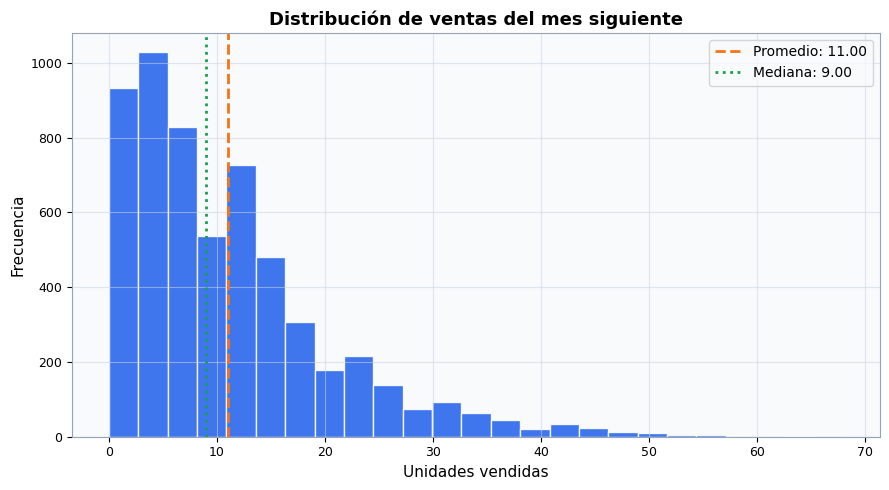

In [6]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    df["ventas_mes_siguiente"],
    bins=25,
    color=COLOR_PRINCIPAL,
    edgecolor="white",
    alpha=0.88,
)
ax.axvline(
    df["ventas_mes_siguiente"].mean(),
    color=COLOR_SECUNDARIO,
    linestyle="--",
    linewidth=2,
    label=f"Promedio: {df['ventas_mes_siguiente'].mean():.2f}",
)
ax.axvline(
    df["ventas_mes_siguiente"].median(),
    color=COLOR_EXITO,
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {df['ventas_mes_siguiente'].median():.2f}",
)
ax.set_title("Distribución de ventas del mes siguiente")
ax.set_xlabel("Unidades vendidas")
ax.set_ylabel("Frecuencia")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


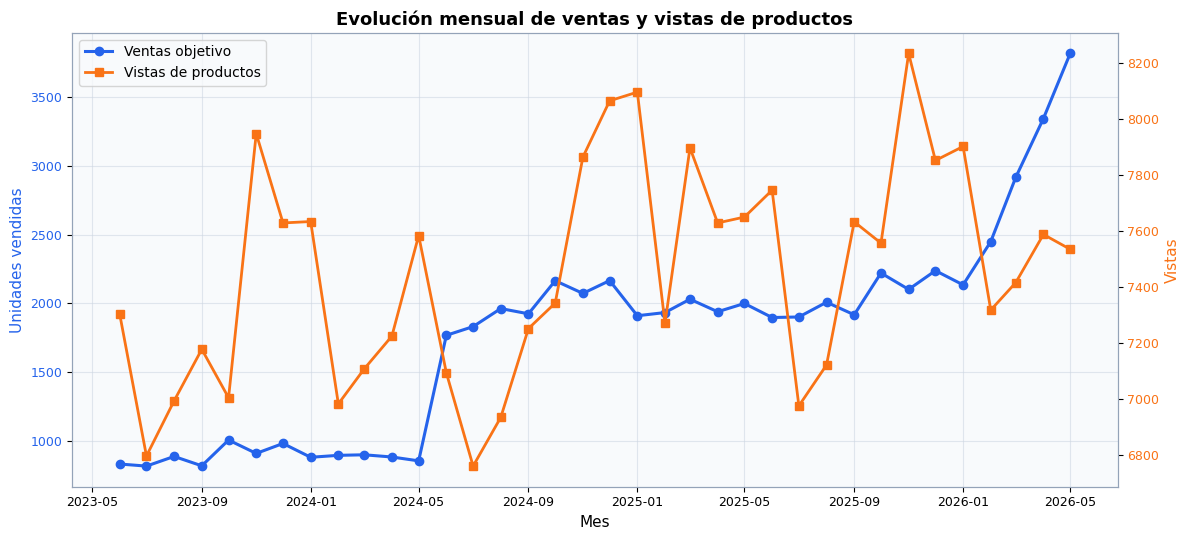

,mes_corte,ventas_objetivo_total,vistas_total
26,2025-08-01,2009,7121
27,2025-09-01,1918,7632
28,2025-10-01,2221,7556
29,2025-11-01,2102,8233
30,2025-12-01,2238,7851
31,2026-01-01,2135,7901
32,2026-02-01,2449,7317
33,2026-03-01,2915,7415
34,2026-04-01,3342,7587
35,2026-05-01,3814,7534


In [7]:
# Evolución mensual total de ventas y vistas
resumen_mensual = (
    df.groupby("mes_corte", as_index=False)
      .agg(
          ventas_objetivo_total=("ventas_mes_siguiente", "sum"),
          vistas_total=("vistas_producto_mes_anterior", "sum"),
      )
)

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.plot(
    resumen_mensual["mes_corte"],
    resumen_mensual["ventas_objetivo_total"],
    marker="o",
    linewidth=2.2,
    color=COLOR_PRINCIPAL,
    label="Ventas objetivo",
)
ax1.set_title("Evolución mensual de ventas y vistas de productos")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Unidades vendidas", color=COLOR_PRINCIPAL)
ax1.tick_params(axis="y", labelcolor=COLOR_PRINCIPAL)

ax2 = ax1.twinx()
ax2.plot(
    resumen_mensual["mes_corte"],
    resumen_mensual["vistas_total"],
    marker="s",
    linewidth=2.0,
    color=COLOR_SECUNDARIO,
    label="Vistas de productos",
)
ax2.set_ylabel("Vistas", color=COLOR_SECUNDARIO)
ax2.tick_params(axis="y", labelcolor=COLOR_SECUNDARIO)
ax2.grid(False)

lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
ax1.legend(lineas_1 + lineas_2, etiquetas_1 + etiquetas_2, loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(resumen_mensual.tail(10))


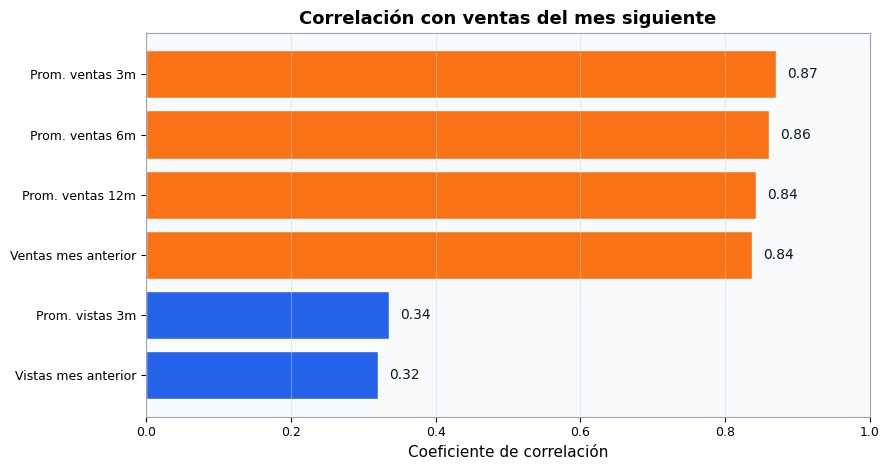

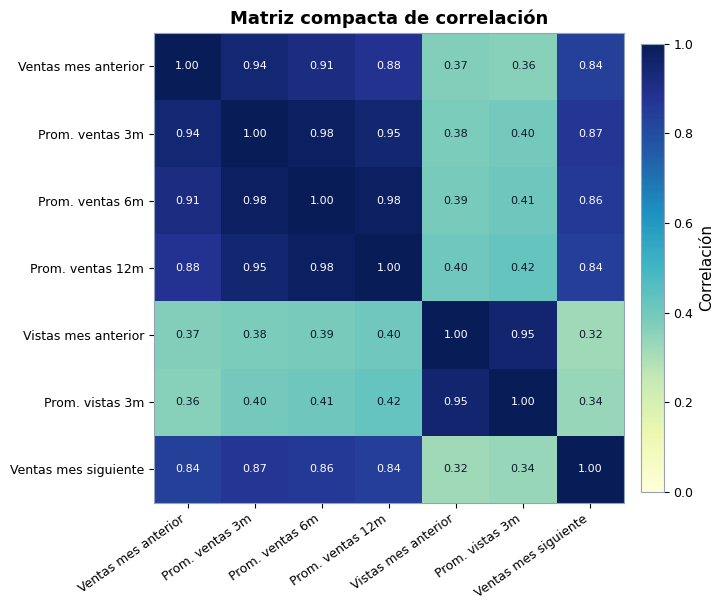

In [8]:
# Relación de las variables históricas con la venta del mes siguiente
correlaciones = df[columnas_numericas].corr()

etiquetas_cortas = {
    "ventas_mes_anterior": "Ventas mes anterior",
    "promedio_movil_ventas_3_meses": "Prom. ventas 3m",
    "promedio_movil_ventas_6_meses": "Prom. ventas 6m",
    "promedio_movil_ventas_12_meses": "Prom. ventas 12m",
    "vistas_producto_mes_anterior": "Vistas mes anterior",
    "promedio_movil_vistas_3_meses": "Prom. vistas 3m",
    "ventas_mes_siguiente": "Ventas mes siguiente",
}

correlacion_objetivo = (
    correlaciones["ventas_mes_siguiente"]
    .drop("ventas_mes_siguiente")
    .sort_values()
    .rename(index=etiquetas_cortas)
)

fig, ax = plt.subplots(figsize=(9, 4.8))
colores = [COLOR_SECUNDARIO if valor >= 0.70 else COLOR_PRINCIPAL for valor in correlacion_objetivo]
ax.barh(
    correlacion_objetivo.index,
    correlacion_objetivo.values,
    color=colores,
    edgecolor="white",
)

for posicion, valor in enumerate(correlacion_objetivo.values):
    ax.text(
        valor + 0.015,
        posicion,
        f"{valor:.2f}",
        va="center",
        fontsize=10,
        color="#0F172A",
    )

ax.set_title("Correlación con ventas del mes siguiente")
ax.set_xlabel("Coeficiente de correlación")
ax.set_xlim(0, 1)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.45)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

# Matriz compacta de correlación para revisar relaciones entre variables.
correlaciones_grafica = correlaciones.rename(
    index=etiquetas_cortas,
    columns=etiquetas_cortas,
)

fig, ax = plt.subplots(figsize=(7.5, 6.2))
imagen = ax.imshow(
    correlaciones_grafica,
    aspect="equal",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

ax.set_xticks(range(len(correlaciones_grafica.columns)))
ax.set_xticklabels(correlaciones_grafica.columns, rotation=35, ha="right")
ax.set_yticks(range(len(correlaciones_grafica.index)))
ax.set_yticklabels(correlaciones_grafica.index)
ax.grid(False)

for fila in range(len(correlaciones_grafica.index)):
    for columna in range(len(correlaciones_grafica.columns)):
        valor = correlaciones_grafica.iloc[fila, columna]
        color_texto = "white" if valor > 0.62 else "#0F172A"
        ax.text(
            columna,
            fila,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=color_texto,
        )

ax.set_title("Matriz compacta de correlación")
barra = fig.colorbar(imagen, ax=ax, fraction=0.038, pad=0.03)
barra.set_label("Correlación")
plt.tight_layout()
plt.show()



## Interpretación inicial

Las variables móviles resumen distintos horizontes del comportamiento histórico:

- El promedio de 3 meses representa el comportamiento reciente.
- El promedio de 6 meses representa una tendencia intermedia.
- El promedio de 12 meses representa una tendencia anual.
- Las vistas del producto representan interés, aunque una vista no garantiza una compra.

Aunque algunas variables estén correlacionadas, **no se eliminarán**, porque el alcance definido requiere utilizar todas las características propuestas.



# 3. Preparación de los datos

## Decisiones

1. `mes_corte` se utiliza únicamente para ordenar y dividir temporalmente.
2. `producto` se transforma mediante codificación **One-Hot**.
3. Las variables numéricas se conservan sin escalamiento porque los modelos principales son basados en árboles.
4. No se realiza selección de características.
5. La división no será aleatoria:
   - 24 meses de entrenamiento.
   - 6 meses de validación.
   - 6 meses de prueba.

Esta división evita que información de meses futuros se utilice para entrenar modelos evaluados en meses anteriores.


In [9]:
# Variables predictoras y objetivo
variables_predictoras = [
    "producto",
    "ventas_mes_anterior",
    "promedio_movil_ventas_3_meses",
    "promedio_movil_ventas_6_meses",
    "promedio_movil_ventas_12_meses",
    "vistas_producto_mes_anterior",
    "promedio_movil_vistas_3_meses",
]

variable_objetivo = "ventas_mes_siguiente"

# Validar columnas
columnas_requeridas = variables_predictoras + ["mes_corte", variable_objetivo]
faltantes = [col for col in columnas_requeridas if col not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas requeridas: {faltantes}")

meses = np.array(sorted(df["mes_corte"].unique()))

if len(meses) < 12:
    raise ValueError("Se necesitan más meses para realizar una división temporal.")

# Para este dataset de 36 meses:
# 24 entrenamiento, 6 validación y 6 prueba.
n_test = 6
n_validacion = 6
n_entrenamiento = len(meses) - n_validacion - n_test

if n_entrenamiento <= 0:
    raise ValueError("No hay suficientes meses para crear los tres subconjuntos.")

mes_fin_entrenamiento = meses[n_entrenamiento - 1]
mes_fin_validacion = meses[n_entrenamiento + n_validacion - 1]

df_train = df[df["mes_corte"] <= mes_fin_entrenamiento].copy()
df_validacion = df[
    (df["mes_corte"] > mes_fin_entrenamiento)
    & (df["mes_corte"] <= mes_fin_validacion)
].copy()
df_test = df[df["mes_corte"] > mes_fin_validacion].copy()

resumen_particion = pd.DataFrame([
    {
        "Conjunto": "Entrenamiento",
        "Inicio": df_train["mes_corte"].min().strftime("%Y-%m"),
        "Fin": df_train["mes_corte"].max().strftime("%Y-%m"),
        "Filas": len(df_train),
    },
    {
        "Conjunto": "Validación",
        "Inicio": df_validacion["mes_corte"].min().strftime("%Y-%m"),
        "Fin": df_validacion["mes_corte"].max().strftime("%Y-%m"),
        "Filas": len(df_validacion),
    },
    {
        "Conjunto": "Prueba",
        "Inicio": df_test["mes_corte"].min().strftime("%Y-%m"),
        "Fin": df_test["mes_corte"].max().strftime("%Y-%m"),
        "Filas": len(df_test),
    },
])

display(resumen_particion)


,Conjunto,Inicio,Fin,Filas
0,Entrenamiento,2023-06,2025-05,3840
1,Validación,2025-06,2025-11,960
2,Prueba,2025-12,2026-05,960


In [10]:
# Separar X e y
X_train = df_train[variables_predictoras]
y_train = df_train[variable_objetivo]

X_validacion = df_validacion[variables_predictoras]
y_validacion = df_validacion[variable_objetivo]

X_test = df_test[variables_predictoras]
y_test = df_test[variable_objetivo]

variables_categoricas = ["producto"]
variables_numericas = [
    variable for variable in variables_predictoras
    if variable not in variables_categoricas
]

def crear_one_hot_encoder():
    # Compatibilidad con distintas versiones de scikit-learn.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            (
                "producto",
                crear_one_hot_encoder(),
                variables_categoricas,
            ),
            (
                "numericas",
                "passthrough",
                variables_numericas,
            ),
        ],
        remainder="drop",
    )

resumen_variables_modelo = pd.DataFrame([
    {"Tipo": "Categóricas", "Variables": ", ".join(variables_categoricas)},
    {"Tipo": "Numéricas", "Variables": ", ".join(variables_numericas)},
    {"Tipo": "Objetivo", "Variables": variable_objetivo},
])

display(resumen_variables_modelo)


,Tipo,Variables
0,Categóricas,producto
1,Numéricas,"ventas_mes_anterior, promedio_movil_ventas_3_m..."
2,Objetivo,ventas_mes_siguiente



# 4. Modelado

Se compararán los siguientes enfoques:

- **Referencia ingenua:** usar las ventas del mes anterior.
- **XGBoost Regressor:** modelo principal solicitado.
- **Random Forest Regressor:** alternativa basada en múltiples árboles.
- **Extra Trees Regressor:** alternativa con mayor aleatoriedad en los árboles.

El modelo final se seleccionará utilizando el menor **MAE de validación**. La prueba final se mantiene separada y no participa en la selección.


In [11]:

def smape(y_real, y_predicha):
    y_real = np.asarray(y_real, dtype=float)
    y_predicha = np.asarray(y_predicha, dtype=float)
    denominador = np.abs(y_real) + np.abs(y_predicha)
    valor = np.where(
        denominador == 0,
        0,
        2 * np.abs(y_predicha - y_real) / denominador
    )
    return float(np.mean(valor) * 100)

def calcular_metricas(y_real, y_predicha):
    return {
        "MAE": mean_absolute_error(y_real, y_predicha),
        "RMSE": mean_squared_error(y_real, y_predicha) ** 0.5,
        "R2": r2_score(y_real, y_predicha),
        "sMAPE_%": smape(y_real, y_predicha),
    }

# Línea base: siguiente mes = mes anterior
pred_validacion_baseline = X_validacion["ventas_mes_anterior"].to_numpy()
metricas_baseline = calcular_metricas(
    y_validacion,
    pred_validacion_baseline
)

display(pd.DataFrame(
    [metricas_baseline],
    index=["Baseline: ventas_mes_anterior"]
).round(4))


,MAE,RMSE,R2,sMAPE_%
Baseline: ventas_mes_anterior,4.3938,5.9767,0.6015,50.4411


In [12]:

# Definir modelos candidatos
modelos = {
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=14,
        min_samples_leaf=2,
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

if XGBOOST_DISPONIBLE:
    modelos["XGBoost"] = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=350,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=2,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.05,
        reg_lambda=1.50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

print("Modelos candidatos:", list(modelos))


Modelos candidatos: ['Random Forest', 'Extra Trees', 'XGBoost']


In [13]:

# Entrenar y evaluar sobre validación
resultados_validacion = []
pipelines_entrenados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(
        steps=[
            ("preprocesamiento", crear_preprocesador()),
            ("modelo", modelo),
        ]
    )

    pipeline.fit(X_train, y_train)
    prediccion = pipeline.predict(X_validacion)

    metricas = calcular_metricas(y_validacion, prediccion)
    metricas["Modelo"] = nombre

    resultados_validacion.append(metricas)
    pipelines_entrenados[nombre] = pipeline

resultados_validacion_df = (
    pd.DataFrame(resultados_validacion)
      .set_index("Modelo")
      .sort_values("MAE")
)

# Incluir baseline para comparación
fila_baseline = pd.DataFrame(
    [metricas_baseline],
    index=["Baseline"]
)

comparacion_validacion = pd.concat(
    [resultados_validacion_df, fila_baseline],
    axis=0
).sort_values("MAE")

display(comparacion_validacion.round(4))


,MAE,RMSE,R2,sMAPE_%
Random Forest,3.5684,4.7901,0.7440,38.1886
Extra Trees,3.5792,4.7700,0.7462,38.4994
XGBoost,3.5804,4.8254,0.7403,38.2546
Baseline,4.3938,5.9767,0.6015,50.4411


In [14]:
# Seleccionar el mejor modelo por MAE de validación
mejor_nombre = resultados_validacion_df.index[0]
mejor_pipeline_validacion = pipelines_entrenados[mejor_nombre]

seleccion_modelo = pd.DataFrame([
    {
        "Modelo seleccionado": mejor_nombre,
        "MAE de validación": round(resultados_validacion_df.loc[mejor_nombre, "MAE"], 4),
        "Criterio": "Menor MAE en validación cronológica",
    }
])

display(seleccion_modelo)

if mejor_nombre != "XGBoost" and XGBOOST_DISPONIBLE:
    display(pd.DataFrame([{
        "Observación": "XGBoost fue evaluado, pero otro modelo obtuvo menor MAE en la validación cronológica."
    }]))


,Modelo seleccionado,MAE de validación,Criterio
0,Random Forest,3.5684,Menor MAE en validación cronológica


,Observación
0,"XGBoost fue evaluado, pero otro modelo obtuvo ..."



# 5. Evaluación final

Después de seleccionar el mejor algoritmo con el conjunto de validación:

1. Se unen entrenamiento y validación.
2. Se vuelve a entrenar el modelo seleccionado.
3. Se evalúa una sola vez sobre los últimos seis meses.

Esto permite evaluar el comportamiento del modelo con datos temporalmente posteriores.


In [15]:
# Unir entrenamiento y validación para el entrenamiento final
df_train_final = pd.concat(
    [df_train, df_validacion],
    axis=0
).sort_values(["mes_corte", "producto"])

X_train_final = df_train_final[variables_predictoras]
y_train_final = df_train_final[variable_objetivo]

# Crear un pipeline nuevo con el modelo seleccionado
modelo_final = clone(modelos[mejor_nombre])

pipeline_final = Pipeline(
    steps=[
        ("preprocesamiento", crear_preprocesador()),
        ("modelo", modelo_final),
    ]
)

pipeline_final.fit(X_train_final, y_train_final)
pred_test = pipeline_final.predict(X_test)

metricas_test = calcular_metricas(y_test, pred_test)

display(pd.DataFrame(
    [{"Modelo final": mejor_nombre, **metricas_test}],
    index=["Prueba final"]
).round(4))


,Modelo final,MAE,RMSE,R2,sMAPE_%
Prueba final,Random Forest,5.1615,6.8787,0.6177,36.14


In [16]:
# Comparación contra baseline en prueba
pred_test_baseline = X_test["ventas_mes_anterior"].to_numpy()
metricas_test_baseline = calcular_metricas(
    y_test,
    pred_test_baseline
)

comparacion_test = pd.DataFrame(
    [
        {"Modelo": mejor_nombre, **metricas_test},
        {"Modelo": "Baseline", **metricas_test_baseline},
    ]
).set_index("Modelo")

display(comparacion_test.round(4))

mejora_mae = (
    (metricas_test_baseline["MAE"] - metricas_test["MAE"])
    / metricas_test_baseline["MAE"]
    * 100
)

display(pd.DataFrame([{
    "Indicador": "Mejora del MAE frente al baseline",
    "Valor": f"{mejora_mae:.2f}%",
}]))


,MAE,RMSE,R2,sMAPE_%
Modelo,,,,
Random Forest,5.1615,6.8787,0.6177,36.1400
Baseline,5.2188,6.8704,0.6186,39.4767


,Indicador,Valor
0,Mejora del MAE frente al baseline,1.10%


In [17]:

# Tabla de predicciones
resultados_test = df_test[
    ["producto", "mes_corte", variable_objetivo]
].copy()

resultados_test["prediccion"] = np.maximum(pred_test, 0)
resultados_test["prediccion_redondeada"] = np.rint(
    resultados_test["prediccion"]
).astype(int)
resultados_test["error_absoluto"] = np.abs(
    resultados_test[variable_objetivo]
    - resultados_test["prediccion"]
)

display(resultados_test.head(15))


,producto,mes_corte,ventas_mes_siguiente,prediccion,prediccion_redondeada,error_absoluto
4800,Adidas Aeroready Tank Negro,2025-12-01,32,30.244971,30,1.755029
4801,Adidas Core Cotton Tank Negro,2025-12-01,4,2.900813,3,1.099187
4802,Adidas Designed 4 Training Tee Negro,2025-12-01,8,10.231429,10,2.231429
4803,Adidas Entrada Jacket Azul Marino,2025-12-01,6,8.411245,8,2.411245
4804,Adidas Essentials Hoodie Gris,2025-12-01,9,8.415587,8,0.584413
4805,Adidas HIIT Training Shorts Negro,2025-12-01,9,8.464215,8,0.535785
4806,Adidas Optime Training Leggings Morado,2025-12-01,6,5.947154,6,0.052846
4807,Adidas Own The Run Tee Verde,2025-12-01,10,9.269077,9,0.730923
4808,Adidas Powerreact Sports Bra Rosa,2025-12-01,7,6.957628,7,0.042372
4809,Adidas Primeblue Track Pants Azul,2025-12-01,7,6.826819,7,0.173181


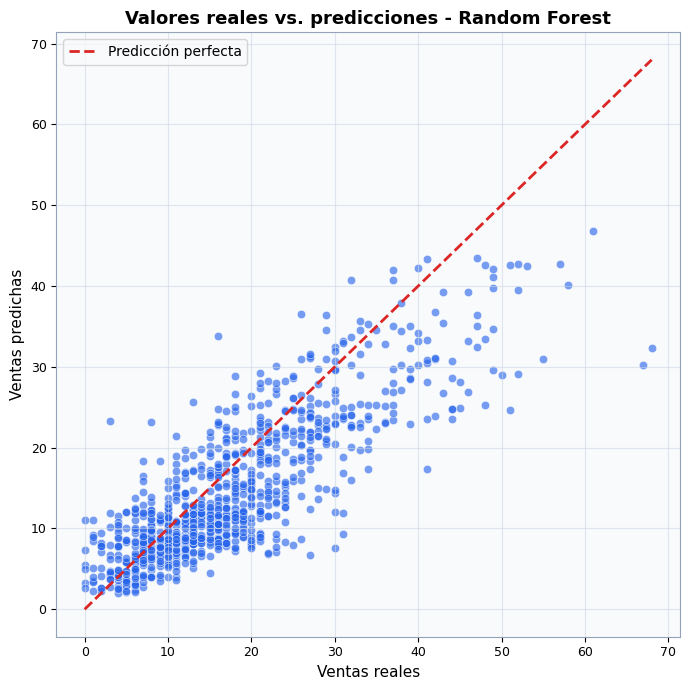

In [18]:
# Valores reales contra predicciones
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    resultados_test[variable_objetivo],
    resultados_test["prediccion"],
    alpha=0.62,
    color=COLOR_PRINCIPAL,
    edgecolor="white",
    linewidth=0.5,
)
limite = max(
    resultados_test[variable_objetivo].max(),
    resultados_test["prediccion"].max(),
)
ax.plot([0, limite], [0, limite], linestyle="--", color=COLOR_ALERTA, linewidth=2, label="Predicción perfecta")
ax.set_title(f"Valores reales vs. predicciones - {mejor_nombre}")
ax.set_xlabel("Ventas reales")
ax.set_ylabel("Ventas predichas")
ax.legend()
plt.tight_layout()
plt.show()


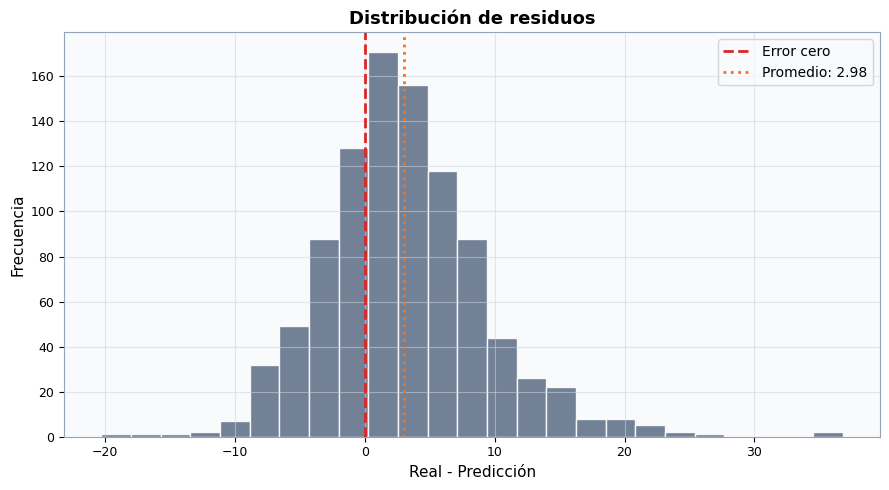

,Métrica,Valor
0,Promedio de residuos,2.9837
1,Mediana de residuos,2.5512


In [19]:
# Distribución de residuos
residuos = (
    resultados_test[variable_objetivo]
    - resultados_test["prediccion"]
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuos, bins=25, color=COLOR_NEUTRO, edgecolor="white", alpha=0.9)
ax.axvline(0, color=COLOR_ALERTA, linestyle="--", linewidth=2, label="Error cero")
ax.axvline(residuos.mean(), color=COLOR_SECUNDARIO, linestyle=":", linewidth=2, label=f"Promedio: {residuos.mean():.2f}")
ax.set_title("Distribución de residuos")
ax.set_xlabel("Real - Predicción")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {"Métrica": "Promedio de residuos", "Valor": round(residuos.mean(), 4)},
    {"Métrica": "Mediana de residuos", "Valor": round(residuos.median(), 4)},
]))


,mes_corte,MAE,ventas_reales,ventas_predichas
0,2025-12-01,3.485,2238,2142.738
1,2026-01-01,3.557,2135,2172.112
2,2026-02-01,4.311,2449,2137.610
3,2026-03-01,5.432,2915,2290.027
4,2026-04-01,6.557,3342,2495.664
5,2026-05-01,7.626,3814,2790.452


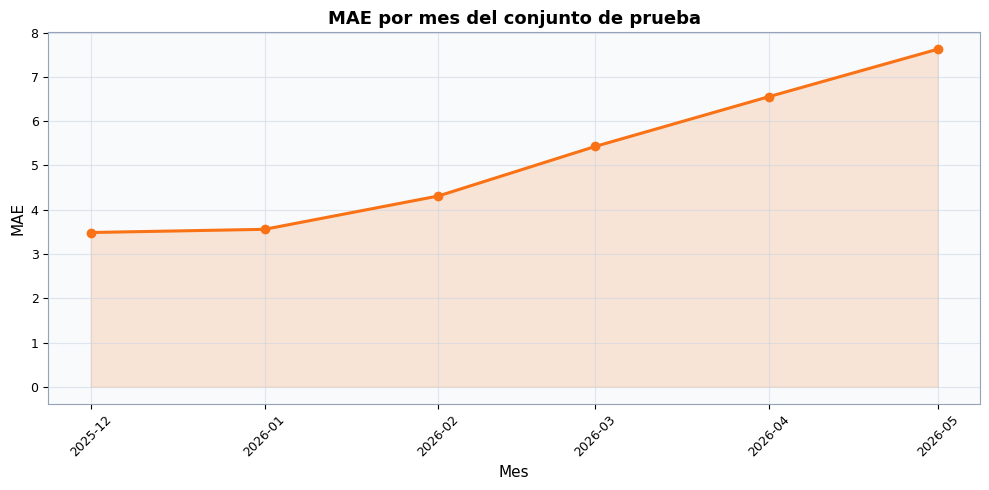

In [20]:
# Error por mes de prueba
error_mensual = (
    resultados_test.groupby("mes_corte", as_index=False)
    .agg(
        MAE=(
            "error_absoluto",
            "mean"
        ),
        ventas_reales=(variable_objetivo, "sum"),
        ventas_predichas=("prediccion", "sum"),
    )
)

display(error_mensual.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    error_mensual["mes_corte"],
    error_mensual["MAE"],
    marker="o",
    linewidth=2.2,
    color=COLOR_SECUNDARIO,
)
ax.fill_between(
    error_mensual["mes_corte"],
    error_mensual["MAE"],
    color=COLOR_SECUNDARIO,
    alpha=0.16,
)
ax.set_title("MAE por mes del conjunto de prueba")
ax.set_xlabel("Mes")
ax.set_ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# Rendimiento por producto
error_producto = (
    resultados_test.groupby("producto", as_index=False)
    .agg(
        MAE=("error_absoluto", "mean"),
        ventas_promedio=(variable_objetivo, "mean"),
        prediccion_promedio=("prediccion", "mean"),
    )
    .sort_values("MAE")
)

productos_menor_error = error_producto.head(10).round(3).assign(grupo="Menor error")
productos_mayor_error = error_producto.tail(10).sort_values("MAE", ascending=False).round(3).assign(grupo="Mayor error")

display(pd.concat([productos_menor_error, productos_mayor_error], axis=0))


,producto,MAE,ventas_promedio,prediccion_promedio,grupo
118,MuscleTech Test HD 90 caps,0.583,9.000,8.801,Menor error
142,Prueba,0.779,4.000,4.016,Menor error
51,Gymshark Sport Jogger Gris Oxford,1.254,7.000,5.866,Menor error
143,Short Deportivo Performance,1.337,8.833,7.709,Menor error
43,Gymshark Everyday Baselayer Blanco,1.901,7.667,6.315,Menor error
79,Harbinger Lifting Chain Collars Negro,2.054,5.333,3.984,Menor error
33,Cellucor Super HD 60 caps,2.112,24.167,23.577,Menor error
44,Gymshark Legacy Tank Azul,2.138,4.833,3.872,Menor error
92,Harbinger Speed Agility Cones Naranja,2.212,5.500,5.196,Menor error
78,Harbinger Lat Pulldown Bar Cromado,2.273,5.333,3.589,Menor error



## Importancia de variables

La importancia se muestra únicamente para interpretar el modelo.

**No se eliminará ninguna característica**, porque la actividad requiere utilizar todas las variables definidas.


,variable,importancia
2,Promedio ventas 3 meses,0.6351
3,Promedio ventas 6 meses,0.2112
1,Promedio ventas 12 meses,0.0485
5,Ventas mes anterior,0.0365
4,Promedio vistas 3 meses,0.0247
0,Producto,0.0232
6,Vistas mes anterior,0.0208


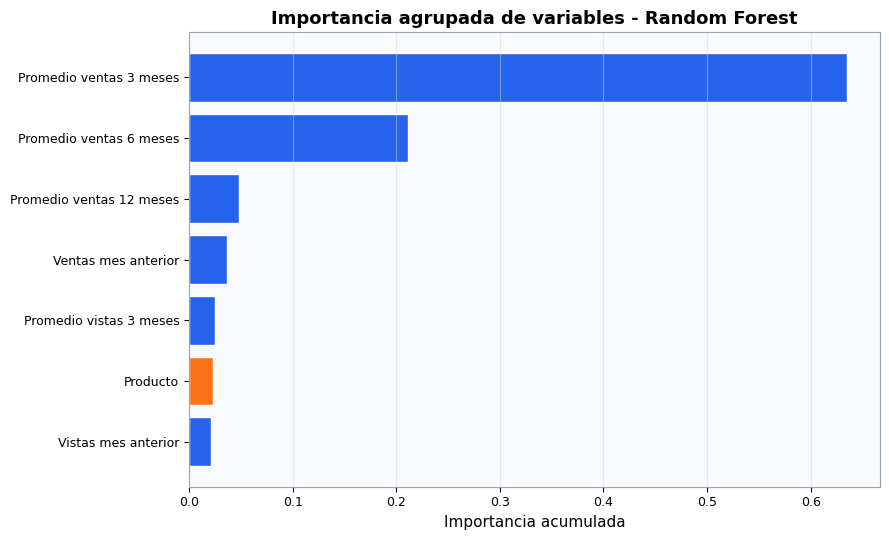

In [22]:
# Importancia de características, cuando el modelo la soporte
preprocesador_entrenado = pipeline_final.named_steps["preprocesamiento"]
modelo_entrenado = pipeline_final.named_steps["modelo"]

if hasattr(modelo_entrenado, "feature_importances_"):
    nombres_transformados = preprocesador_entrenado.get_feature_names_out()

    importancias = pd.DataFrame({
        "caracteristica_transformada": nombres_transformados,
        "importancia": modelo_entrenado.feature_importances_,
    })

    def variable_original(nombre):
        if nombre.startswith("producto__producto_"):
            return "producto"
        if nombre.startswith("numericas__"):
            return nombre.replace("numericas__", "")
        return nombre

    importancias["variable_original"] = importancias[
        "caracteristica_transformada"
    ].apply(variable_original)

    importancias_agrupadas = (
        importancias.groupby("variable_original", as_index=False)
        .agg(importancia=("importancia", "sum"))
        .sort_values("importancia", ascending=False)
    )

    etiquetas_importancia = {
        "producto": "Producto",
        "ventas_mes_anterior": "Ventas mes anterior",
        "promedio_movil_ventas_3_meses": "Promedio ventas 3 meses",
        "promedio_movil_ventas_6_meses": "Promedio ventas 6 meses",
        "promedio_movil_ventas_12_meses": "Promedio ventas 12 meses",
        "vistas_producto_mes_anterior": "Vistas mes anterior",
        "promedio_movil_vistas_3_meses": "Promedio vistas 3 meses",
    }
    importancias_agrupadas["variable"] = importancias_agrupadas[
        "variable_original"
    ].map(etiquetas_importancia).fillna(importancias_agrupadas["variable_original"])

    display(importancias_agrupadas[["variable", "importancia"]].round(4))

    fig, ax = plt.subplots(figsize=(9, 5.5))
    datos_grafica = importancias_agrupadas.sort_values("importancia")
    colores = [COLOR_PRINCIPAL if variable != "Producto" else COLOR_SECUNDARIO for variable in datos_grafica["variable"]]
    ax.barh(
        datos_grafica["variable"],
        datos_grafica["importancia"],
        color=colores,
        edgecolor="white",
    )
    ax.set_title(f"Importancia agrupada de variables - {mejor_nombre}")
    ax.set_xlabel("Importancia acumulada")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.45)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()
else:
    display(pd.DataFrame([{
        "Observación": "El modelo seleccionado no expone feature_importances_. Esto no afecta su evaluación."
    }]))



# 6. Despliegue

La fase de despliegue de CRISP-DM no implica necesariamente publicar una aplicación completa. En esta libreta se realizará una preparación técnica básica:

- Guardar el pipeline completo.
- Guardar las predicciones de prueba.
- Crear una función para predecir un nuevo registro.
- Documentar las entradas esperadas.

El pipeline guardado incluye tanto la codificación del producto como el modelo.


In [23]:
# Guardar el modelo y resultados
carpeta_salida = Path("salidas_regresion")
carpeta_salida.mkdir(exist_ok=True)

ruta_modelo = carpeta_salida / "modelo_ventas_productos.joblib"
ruta_predicciones = carpeta_salida / "predicciones_prueba.csv"
ruta_metricas = carpeta_salida / "metricas_modelo.json"

joblib.dump(pipeline_final, ruta_modelo)

resultados_exportar = resultados_test.copy()
resultados_exportar["mes_corte"] = resultados_exportar[
    "mes_corte"
].dt.strftime("%Y-%m")
resultados_exportar.to_csv(
    ruta_predicciones,
    index=False,
    encoding="utf-8-sig",
)

metricas_exportar = {
    "modelo": mejor_nombre,
    **{
        clave: float(valor)
        for clave, valor in metricas_test.items()
    },
    "periodo_prueba_inicio": df_test["mes_corte"].min().strftime("%Y-%m"),
    "periodo_prueba_fin": df_test["mes_corte"].max().strftime("%Y-%m"),
    "variables_predictoras": variables_predictoras,
    "variable_objetivo": variable_objetivo,
}

with open(ruta_metricas, "w", encoding="utf-8") as archivo:
    json.dump(metricas_exportar, archivo, ensure_ascii=False, indent=2)

archivos_generados = pd.DataFrame([
    {"Artefacto": "Modelo", "Ruta": str(ruta_modelo.resolve())},
    {"Artefacto": "Predicciones", "Ruta": str(ruta_predicciones.resolve())},
    {"Artefacto": "Métricas", "Ruta": str(ruta_metricas.resolve())},
])

display(archivos_generados)


,Artefacto,Ruta
0,Modelo,C:\Users\castr\OneDrive\Escritorio\prueba\entr...
1,Predicciones,C:\Users\castr\OneDrive\Escritorio\prueba\entr...
2,Métricas,C:\Users\castr\OneDrive\Escritorio\prueba\entr...


In [24]:
def predecir_ventas_siguiente_mes(
    pipeline,
    producto,
    ventas_mes_anterior,
    promedio_movil_ventas_3_meses,
    promedio_movil_ventas_6_meses,
    promedio_movil_ventas_12_meses,
    vistas_producto_mes_anterior,
    promedio_movil_vistas_3_meses,
):
    entrada = pd.DataFrame([{
        "producto": producto,
        "ventas_mes_anterior": ventas_mes_anterior,
        "promedio_movil_ventas_3_meses": promedio_movil_ventas_3_meses,
        "promedio_movil_ventas_6_meses": promedio_movil_ventas_6_meses,
        "promedio_movil_ventas_12_meses": promedio_movil_ventas_12_meses,
        "vistas_producto_mes_anterior": vistas_producto_mes_anterior,
        "promedio_movil_vistas_3_meses": promedio_movil_vistas_3_meses,
    }])

    prediccion = float(pipeline.predict(entrada)[0])
    prediccion = max(prediccion, 0)

    return {
        "prediccion_decimal": prediccion,
        "unidades_estimadas": int(round(prediccion)),
    }

# Ejemplo con el primer registro del conjunto de prueba
ejemplo = X_test.iloc[0]

resultado_ejemplo = predecir_ventas_siguiente_mes(
    pipeline=pipeline_final,
    producto=ejemplo["producto"],
    ventas_mes_anterior=ejemplo["ventas_mes_anterior"],
    promedio_movil_ventas_3_meses=ejemplo[
        "promedio_movil_ventas_3_meses"
    ],
    promedio_movil_ventas_6_meses=ejemplo[
        "promedio_movil_ventas_6_meses"
    ],
    promedio_movil_ventas_12_meses=ejemplo[
        "promedio_movil_ventas_12_meses"
    ],
    vistas_producto_mes_anterior=ejemplo[
        "vistas_producto_mes_anterior"
    ],
    promedio_movil_vistas_3_meses=ejemplo[
        "promedio_movil_vistas_3_meses"
    ],
)

display(pd.DataFrame([{
    "Producto": ejemplo["producto"],
    "Predicción decimal": round(resultado_ejemplo["prediccion_decimal"], 4),
    "Unidades estimadas": resultado_ejemplo["unidades_estimadas"],
    "Valor real": int(y_test.loc[ejemplo.name]),
}]))x

,Producto,Predicción decimal,Unidades estimadas,Valor real
0,Adidas Aeroready Tank Negro,30.245,30,32



# Conclusiones

Al ejecutar la libreta se debe analizar:

1. Qué modelo obtuvo el menor MAE en validación.
2. Si el modelo final superó a la referencia de usar las ventas del mes anterior.
3. Cuánto se equivoca, en promedio, en unidades.
4. Si los residuos se encuentran razonablemente centrados en cero.
5. Qué productos y meses presentan mayor error.
6. Si las vistas aportan información complementaria a las ventas históricas.

## Consideraciones

- Las predicciones son estimaciones, no cantidades garantizadas.
- `mes_corte` se excluyó del entrenamiento y solo se utilizó para la división temporal.
- Todas las demás variables propuestas fueron utilizadas.
- No se realizó selección de características.
- Si los datos históricos son simulados, los resultados demuestran el proceso técnico, pero no sustituyen una validación futura con ventas reales.
- El modelo debe reentrenarse cuando se acumulen nuevos meses.
